## Setup and Theory (Testing feature selection using linear kernels)
I will choose $\sigma^2$ to be 2.0 and generate data points $X$ of size $n \times p$ where $n=100$ and $p=10$ from a multivariate normal $$\mathcal{N}(0, I_p)$$.
Then I will compute the kernel matrix $K$ using the linear kernel formula, for all pairs of data points in $X$. 
so $K$ will look like:
$$K^{true}_{ij} = 2.0 \cdot X_i^{(T, :p-2)} X_j^{(:p-2)}$$
where $X_i$ and $X_j$ are the $i^{th}$ and $j^{th}$ rows of $X$ respectively, and $X^{(:p-2)}$ means taking the first $p-2$ features only. ()

After that, I will use our network with: 
$$K_{(i,j)}^{(k)} = K^{(k)}(f^{(k)}(x_i^{(k)}), f^{(k)}(x_j^{(k)}))$$

And then to get the entry $$K_{(i,j)}= \sum_{k=1}^{p} \alpha_k K_{(i,j)}^{(k)}$$

The learnable parameters will be $ K^{(k)}$ and $\alpha_k$ . Later on we will navigate to learning the functional form of each $f^{(k)}$ as well. And so for now we will fix $f^{(k)}$ to be the identity function for now (i.e. $f^{(k)}(x) = x$).

<!-- Now what I mean by $f^{(k)}$ is a learnable transformation from the k'th feature to some other space (i.e. $f^{(k)}: \mathbb{R} \rightarrow \mathbb{R}^{d_k}$ where $d_k=1$ for now). We will also fix this to be a non-linear of a linear transformation for this experiment (i.e. $f^{(k)}(x) = \tau (w_k x + b_k)$ where $w_k, b_k$ are learnable parameters), and $\tau$ is a non-linear activation function (ReLU, Tanh, Sigmoid, etc). (For this experiment I will choose $\tau=RelU$) -->

Now what I mean by $K^{(k)}$ is learning the parameters of the kernel function (which in this case is the linear kernel). So for the linear kernel we have:
$$K^{(k)}(X_i,X_j) = \alpha_k \sigma_k^2 X_i^{(k)} X_j^{(k)}$$
where $\sigma_k^2$ is a learnable parameter.

So in short the learnable parameters are:
- $\sigma_k^2$ for $k=1,...,p$ which I am gonna initialize using a $\mathcal{N}(1.0, 0.1)$
- $\alpha_k$ for $k=1,...,p$ which I am gonna initialize using a $\mathcal{N}(1.0, 0.1)$



In this case I added this noise to the kernel matrix in 
* Adding noise to every entry (i.e. $K^{true}_{observed} = K^{true} + N$ where $N_{ij} \sim \mathcal{N}(0, \sigma_{noise}^2)$ i.i.d)


Now for the objective function we will minimize the Frobenius norm between the true kernel matrix and the learned kernel matrix:
$$L = ||K^{true}_{observed} - K||_F^2$$
**BUT** since the Frobenius norm results in very large values and makes the training unstable, I will minimize the mean squared error between the two matrices instead (PLUS a sparsity penalty on the alphas):
$$L = \frac{1}{n^2} \sum_{i=1}^{n} \sum_{j=1}^{n} (K^{true}_{observed,ij} - K_{ij})^2 + \lambda \sum_{k=1}^p |\alpha_k|$$

**NOTE**: we do not care to compute the loss on all entries of ther kernel matrix, since by construction the kernel matrix is symmetric and positive definite. So we can compute the loss on the upper triangular part of the matrix only (including the diagonal). But for simplicity I will compute the loss on all entries for now.

## results anlysis
We can see how the model indeed learned to put high weights on the first p-2 features and very low weights on the last two features.

## How to run: 
* Just run all cells in order.

In [1]:
import torch
import matplotlib.pyplot as plt

#### generation of data and true kernel matrix K_TRUE

In [14]:
torch.manual_seed(0)
n = 200
p = 20
X = torch.distributions.multivariate_normal.MultivariateNormal(
    loc=torch.ones(p),
    covariance_matrix=torch.eye(p)
).sample((n,))  # (n, p)
true_sigma_square = 2.0
nb_removed_features = 2
# the TRUE kernel will use all p features except the last two (i.e. it is a kernel on first p-2 features)
X_true = X[:, :-nb_removed_features]  # (n, p-nb_removed_features)
print(X_true.shape)  # (n, p-nb_removed_features)
noise_sigma_square = 0.1
noise_matrix = noise_sigma_square * torch.eye(n)  # (n, n)
K_TRUE = true_sigma_square * (X_true @ X_true.t()) # i.e. f(x) in y=f(x) + e
K_observed = K_TRUE + noise_matrix
print(K_TRUE.shape)  # (n, n)

torch.Size([200, 18])
torch.Size([200, 200])


In [17]:
# Define a range of lambda_lasso values to test
lambda_lasso_values = [ 0.1, 1.0, 10.0] # 0.001, 0.0001, 0.002,0.003,0.005,0.01, 0.05,
best_lambda = None
best_loss = float('inf')
losses_for_lambdas = {}
best_sigmas = None
best_alphas = None

for lambda_lasso in lambda_lasso_values:
    # Reinitialize parameters
    sigmas_pred = torch.distributions.normal.Normal(1.0, 0.1).sample((p, 1)).requires_grad_(True)
    alphas_pred = torch.distributions.normal.Normal(1.0, 0.1).sample((p, 1)).requires_grad_(True)
    learning_rate = 0.001
    epochs = 2000
    mse_losses = []

    for epoch in range(epochs):
        # Compute weights
        weights = (alphas_pred * (sigmas_pred ** 2)).view(1, p)

        # Compute K_pred
        X_weighted = X * weights
        K_pred = X_weighted @ X.T

        # Compute loss
        diff = K_observed - K_pred
        mse_loss = (diff * diff).mean()
        sparsity_penalty = lambda_lasso * torch.sum(torch.abs(alphas_pred))
        # mse_loss += sparsity_penalty
        mse_losses.append(mse_loss.item())

        # Backpropagation
        mse_loss.backward()

        # Manual SGD update
        with torch.no_grad():
            sigmas_pred -= learning_rate * sigmas_pred.grad
            alphas_pred -= learning_rate * alphas_pred.grad
            sigmas_pred.grad.zero_()
            alphas_pred.grad.zero_()

    # Store the final loss for this lambda_lasso
    final_loss = mse_losses[-1]
    losses_for_lambdas[lambda_lasso] = final_loss

    # Update the best lambda if this one is better
    if final_loss < best_loss:
        best_loss = final_loss
        best_lambda = lambda_lasso
        best_sigmas = sigmas_pred.detach().clone()
        best_alphas = alphas_pred.detach().clone()

# Print the results
print("Best lambda_lasso:", best_lambda)
print(f"learned alphas: {best_alphas.view(-1)}")
print(f"learned sigmas^2: {(best_sigmas.view(-1) ** 2)}")


Best lambda_lasso: 1.0
learned alphas: tensor([1.2127, 0.9782, 1.2995, 1.2049, 1.2185, 1.1349, 1.2577, 1.0850, 1.1781,
        1.0891, 1.3062, 1.2466, 1.2224, 1.1557, 1.1006, 1.1815, 1.2449, 1.1883,
        0.8351, 0.8449])
learned sigmas^2: tensor([1.6476, 2.0427, 1.5380, 1.6586, 1.6394, 1.7589, 1.5891, 1.8408, 1.6961,
        1.8342, 1.5298, 1.6050, 1.6340, 1.7310, 1.8147, 1.6895, 1.6033, 1.6817,
        0.0341, 0.0273])


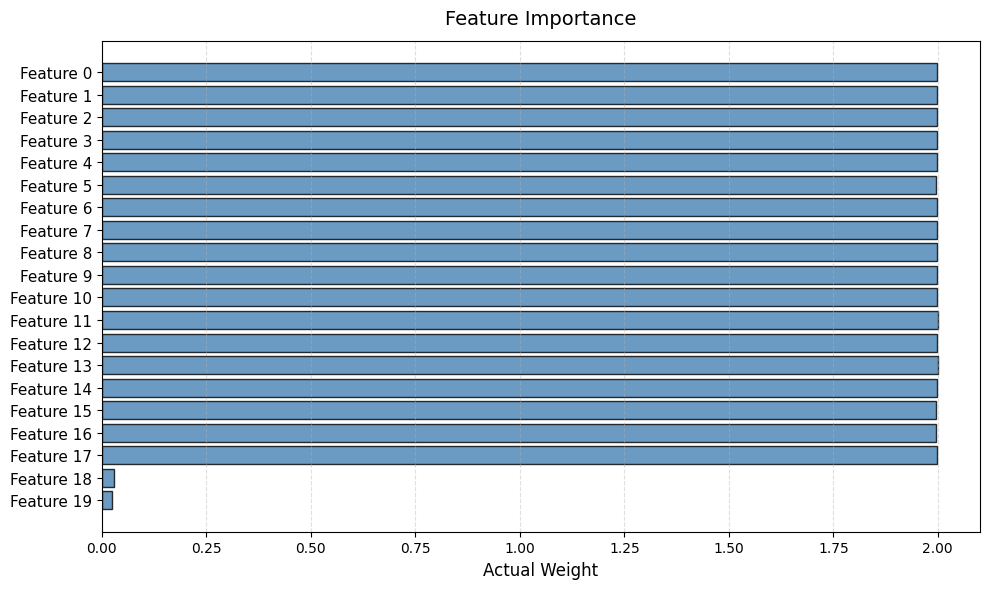

In [18]:
# Normalize alphas
# weight = best_alphas * (best_sigmas ** 2)
best_weight = best_alphas * (best_sigmas ** 2)

normalized_weight = best_weight / best_weight.sum()

# Convert to NumPy (detached)
vals = best_weight.detach().numpy().flatten()

# Reverse order (highest feature index at top)
vals = vals[::-1]

# Professional feature names
feature_labels = [f"Feature {i}" for i in range(len(vals)-1, -1, -1)]

plt.figure(figsize=(10, 6))

# Horizontal bar plot
plt.barh(
    y=range(len(vals)),
    width=vals,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

plt.yticks(range(len(vals)), feature_labels, fontsize=11)
plt.xlabel("Actual Weight", fontsize=12)
plt.title("Feature Importance", fontsize=14, pad=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("feature_importance_linear_kernel.png", dpi=300)
plt.show()
